# Paper Figures: When Not to Estimate

4-page paper figure generation. 3 configs: ELAA 15GHz, ELAA 28GHz, 5G MIMO 3.5GHz.

**Logic flow:**
1. Fig 2: Channel varies slowly → skip is feasible
2. Fig 3: Skipping at noise floor level doesn't hurt NMSE
3. Fig 4: LS delta is practical best feature for scheduling
4. Fig 5: Path diversity determines skip feasibility (not speed alone)

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3,4,5,6"

import sys; sys.path.insert(0, "../..")
import json, numpy as np, matplotlib.pyplot as plt, torch
from pathlib import Path
from src.experiments.pipeline import (
    load_all_ues, _precompute_deltas, _vectorized_scheduling, 
    _compute_nmse_from_tiers, SPEED_LABELS
)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 10, "figure.dpi": 150})

PRESETS = ["munich_elaa_m_1k_15g", "munich_elaa_m_1k_28g", "munich_5g_mimo_3g5"]
PRESET_LABELS = {"munich_elaa_m_1k_15g": "ELAA 15GHz", "munich_elaa_m_1k_28g": "ELAA 28GHz", "munich_5g_mimo_3g5": "5G 3.5GHz"}
MAX_SNAPSHOTS = 1000  # shorter for paper (speed)
UE_PER_SPEED = 2

# Load all 3 configs
all_ue_data = {}
for preset in PRESETS:
    try:
        ud = load_all_ues(preset, max_snapshots=MAX_SNAPSHOTS, ue_per_speed=UE_PER_SPEED)
        all_ue_data[preset] = ud
        print(f"  {PRESET_LABELS[preset]}: {len(ud['ue_list'])} UEs, {ud['max_snapshots']} snaps")
    except Exception as e:
        print(f"  {PRESET_LABELS[preset]}: FAILED ({e})")
        all_ue_data[preset] = None

print(f"\nLoaded: {sum(1 for v in all_ue_data.values() if v is not None)}/3 configs")

Loaded munich_elaa_m_1k_15g: 1000 snaps, 9 UEs, dt=0.00025s


CIR→CFR (5 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (5 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (5 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (5 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

...

CIR→CFR (5 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (5 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (5 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (5 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

Loaded 6 UEs into RAM (1.6 GB)
  5G 3.5GHz: 6 UEs, 1000 snaps

Loaded: 3/3 configs


## Fig 2: Oracle δ(t) — Channel varies slowly
**Message**: Most slots have δ << 0.1. Skip is fundamentally feasible.
3 rows (static/ped/veh), 3 cols (configs). LS noise floor overlay.

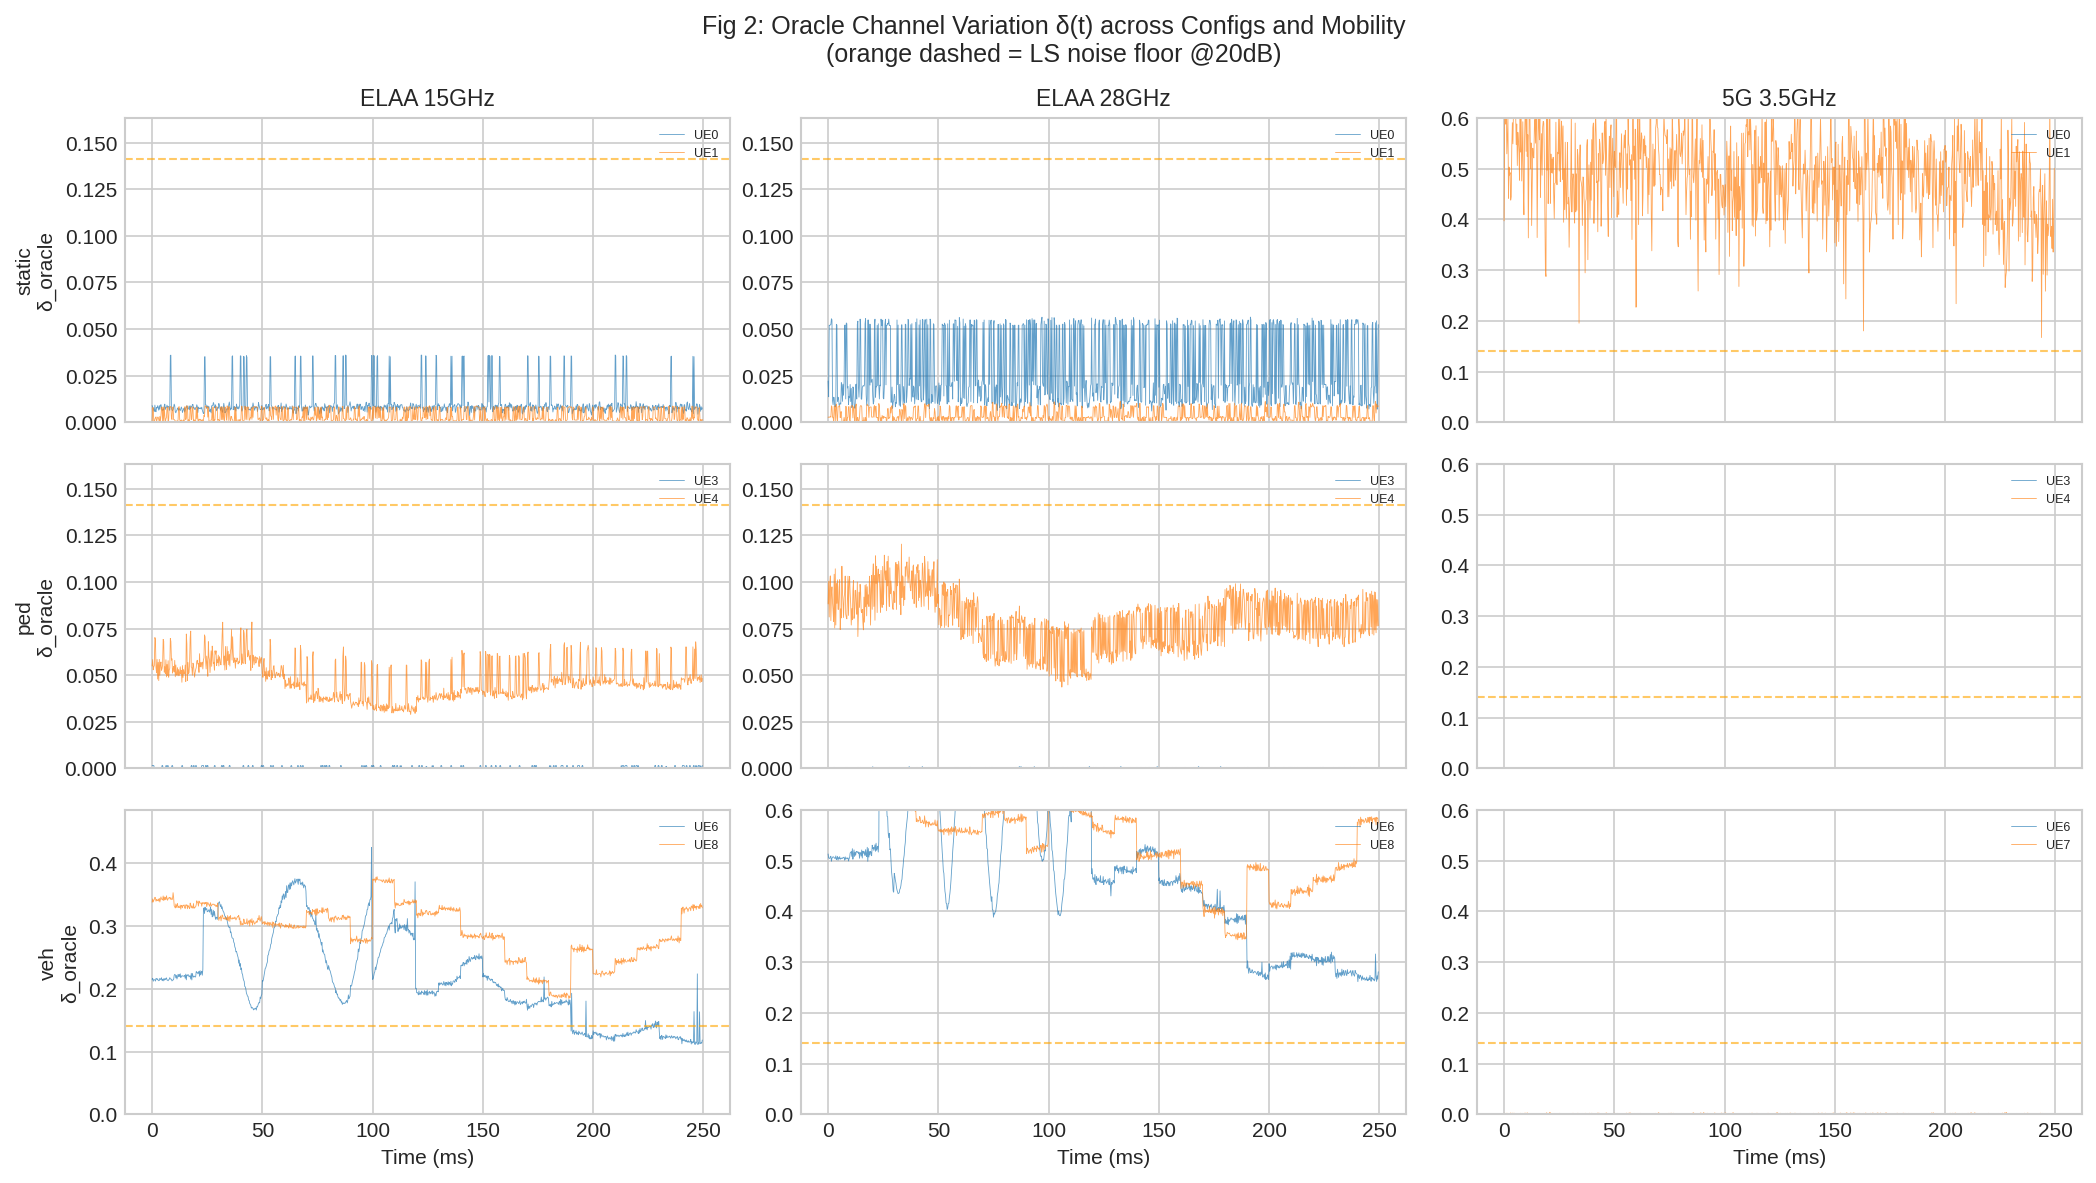

In [2]:
# Fig 2: Oracle δ time series — 3 speeds × 3 configs
fig, axes = plt.subplots(3, 3, figsize=(14, 8), sharex=True)
dt_ms = 0.25
noise_floor_20dB = np.sqrt(2.0 / 100)  # ≈ 0.141

speed_order = ["static", "ped", "veh"]

for col, preset in enumerate(PRESETS):
    ud = all_ue_data.get(preset)
    if ud is None:
        for row in range(3):
            axes[row, col].text(0.5, 0.5, "No data", ha="center", va="center", transform=axes[row, col].transAxes)
        continue
    
    groups = {"static": [], "ped": [], "veh": []}
    for u in ud["ue_list"]:
        lbl = "static" if u["speed"] < 0.1 else ("ped" if u["speed"] < 5 else "veh")
        groups[lbl].append(u)
    
    for row, spd_label in enumerate(speed_order):
        ax = axes[row, col]
        for u in groups.get(spd_label, []):
            h = u["h_real"]
            diff = h[1:] - h[:-1]
            ref = h[:-1].flatten(1).norm(dim=1).clamp(min=1e-12)
            delta = (diff.flatten(1).norm(dim=1) / ref).numpy()
            t_ms = np.arange(len(delta)) * dt_ms
            ax.plot(t_ms, delta, lw=0.4, alpha=0.7, label=f"UE{u['uid']}")
        
        ax.axhline(noise_floor_20dB, color="orange", ls="--", lw=1, alpha=0.6)
        ax.set_ylim(0, min(0.6, ax.get_ylim()[1] * 1.1) if groups.get(spd_label) else 0.6)
        if row == 0:
            ax.set_title(PRESET_LABELS[preset], fontsize=11)
        if col == 0:
            ax.set_ylabel(f"{spd_label}\nδ_oracle")
        if row == 2:
            ax.set_xlabel("Time (ms)")
        ax.legend(fontsize=6, loc="upper right")

fig.suptitle("Fig 2: Oracle Channel Variation δ(t) across Configs and Mobility\n"
             "(orange dashed = LS noise floor @20dB)", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig2_delta_timeseries.pdf", bbox_inches="tight")
plt.show()

## Fig 3: NMSE vs Threshold — noise floor is safe skip level

### LS Monitor Noise Floor Derivation

In OFDM systems, the LS channel estimate at subcarrier $k$ is:

$$\hat{H}_{\text{LS}}[k] = \frac{Y[k]}{X[k]} = H[k] + \frac{N[k]}{X[k]}$$

where $Y[k]$ is the received DMRS, $X[k]$ is the known pilot, $N[k] \sim \mathcal{CN}(0, \sigma^2_n)$ is AWGN.

The **Channel Estimation Error Variance** of the LS estimator is:

$$\sigma^2_{\text{CE}} = \mathbb{E}\left[|\hat{H}_{\text{LS}} - H|^2\right] = \frac{\sigma^2_n}{|X|^2} = \frac{\sigma^2_n}{E_p} = \frac{1}{\text{SNR}}$$

where $E_p = |X|^2$ is the pilot energy. At SNR = 20 dB: $\sigma^2_{\text{CE}} = 0.01$.

Now, the scheduling monitor computes the **normalized LS difference**:

$$\delta_{\text{LS}}(t) = \frac{\|\hat{\mathbf{h}}_{\text{LS}}(t) - \hat{\mathbf{h}}_{\text{LS}}(t-1)\|}{\|\hat{\mathbf{h}}_{\text{LS}}(t-1)\|}$$

For a **static channel** ($\mathbf{h}(t) = \mathbf{h}(t-1)$), the numerator reduces to the difference of two independent noise vectors:

$$\hat{\mathbf{h}}_{\text{LS}}(t) - \hat{\mathbf{h}}_{\text{LS}}(t-1) = \mathbf{n}(t) - \mathbf{n}(t-1)$$

where $\mathbf{n}(t), \mathbf{n}(t-1) \sim \mathcal{CN}(\mathbf{0}, \sigma^2_{\text{CE}} \mathbf{I})$ are i.i.d. The squared norm:

$$\mathbb{E}\left[\|\mathbf{n}(t) - \mathbf{n}(t-1)\|^2\right] = 2 \sigma^2_{\text{CE}} \cdot D = \frac{2D}{\text{SNR}}$$

where $D = N_{\text{ant}} \times N_{\text{sc}}$ is the total channel dimension. Meanwhile:

$$\mathbb{E}\left[\|\hat{\mathbf{h}}_{\text{LS}}\|^2\right] \approx \|\mathbf{h}\|^2 + \sigma^2_{\text{CE}} \cdot D \approx \|\mathbf{h}\|^2 \quad (\text{high SNR})$$

Therefore the **noise floor** of $\delta_{\text{LS}}$ is:

$$\boxed{\delta_{\text{floor}} = \sqrt{\frac{2}{\text{SNR}_{\text{linear}}}} \approx 0.141 \quad \text{at 20 dB}}$$

**Physical interpretation**: Even when the channel is perfectly static, the LS monitor reports $\delta \approx 0.14$ due to estimation noise. Any true channel variation with $\delta_{\text{oracle}} < \delta_{\text{floor}}$ is **masked by noise** and cannot be detected by the LS monitor.

**Implication for scheduling**: Setting $\tau = \delta_{\text{floor}}$ means the scheduler skips CE whenever the *observed* variation is below the noise floor. For static/slow UEs where $\delta_{\text{oracle}} \ll \delta_{\text{floor}}$, this is safe — the "variation" is entirely noise.

Fig3 ELAA 15GHz:   0%|          | 0/6 [00:00<?, ?it/s]

Fig3 ELAA 28GHz:   0%|          | 0/6 [00:00<?, ?it/s]

Fig3 5G 3.5GHz:   0%|          | 0/6 [00:00<?, ?it/s]

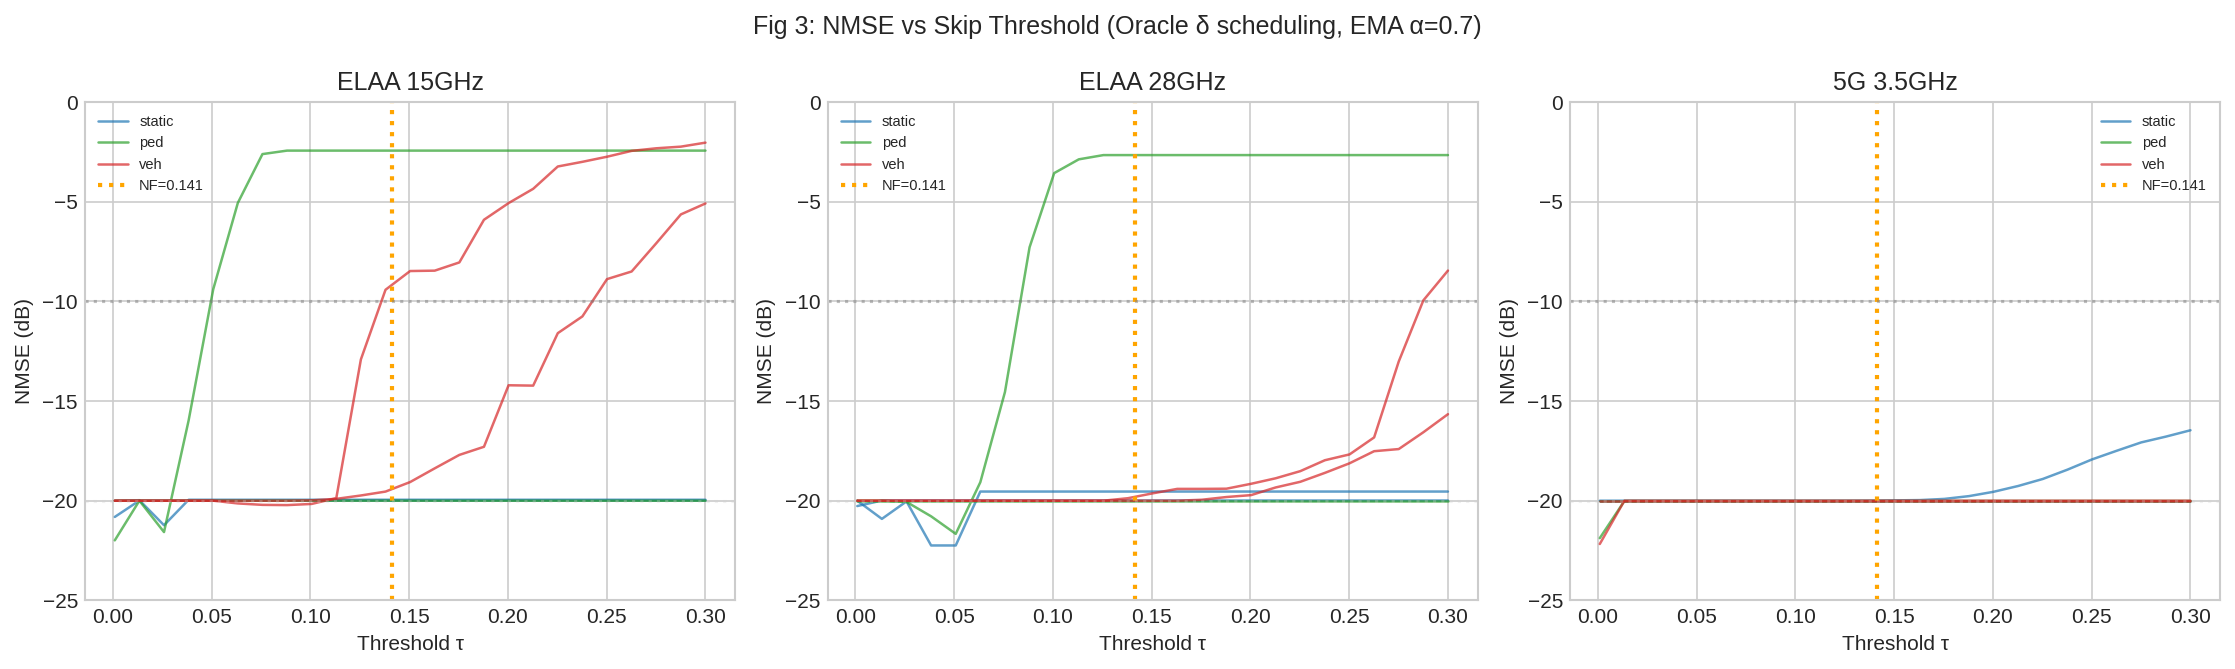

In [3]:
# Fig 3: NMSE vs τ — noise floor skip test across all configs
from tqdm.auto import tqdm

SNR_DB = 20.0
noise_floor = np.sqrt(2.0 / (10 ** (SNR_DB / 10)))
thresholds = np.linspace(0.001, 0.3, 25)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
speed_colors = {"static": "tab:blue", "ped": "tab:green", "veh": "tab:red"}

for col, preset in enumerate(PRESETS):
    ax = axes[col]
    ud = all_ue_data.get(preset)
    if ud is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        continue
    
    for u in tqdm(ud["ue_list"], desc=f"Fig3 {PRESET_LABELS[preset]}", leave=False):
        h = u["h_real"]
        h_ls, d_ls, d_oracle, _ = _precompute_deltas(h, SNR_DB)
        lbl = "static" if u["speed"] < 0.1 else ("ped" if u["speed"] < 5 else "veh")
        color = speed_colors[lbl]
        
        # Oracle scheduling sweep
        nmses_o = []
        for tau in thresholds:
            sched = _vectorized_scheduling(d_oracle, tau_low=tau, tau_high=2*tau)
            nm = _compute_nmse_from_tiers(h, h_ls, sched["tiers"], alpha=0.7, delta_mode="ema")
            nmses_o.append(10 * np.log10(max(np.mean(nm), 1e-30)))
        
        ax.plot(thresholds, nmses_o, "-", color=color, lw=1.2, alpha=0.7,
                label=f"{lbl}" if u == [x for x in ud["ue_list"] if ("static" if x["speed"]<0.1 else "ped" if x["speed"]<5 else "veh") == lbl][0] else "")
    
    ax.axvline(noise_floor, color="orange", ls=":", lw=2, label=f"NF={noise_floor:.3f}")
    ax.axhline(-10, color="gray", ls=":", alpha=0.5)
    ax.axhline(-20, color="lightgray", ls=":", alpha=0.3)
    ax.set_xlabel("Threshold τ"); ax.set_ylabel("NMSE (dB)")
    ax.set_title(PRESET_LABELS[preset])
    ax.legend(fontsize=7)
    ax.set_ylim(-25, 0)

fig.suptitle("Fig 3: NMSE vs Skip Threshold (Oracle δ scheduling, EMA α=0.7)", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig3_nmse_vs_tau.pdf", bbox_inches="tight")
plt.show()

## Fig 4: Feature Comparison Pareto — SR vs NMSE
**Message**: LS delta is practical best. Oracle delta is upper bound. Decorrelation and power delta are alternatives.
3 panels (configs), 6 feature curves per panel.

Fig4 ELAA 15GHz:   0%|          | 0/6 [00:00<?, ?it/s]

Fig4 ELAA 28GHz:   0%|          | 0/6 [00:00<?, ?it/s]

Fig4 5G 3.5GHz:   0%|          | 0/6 [00:00<?, ?it/s]

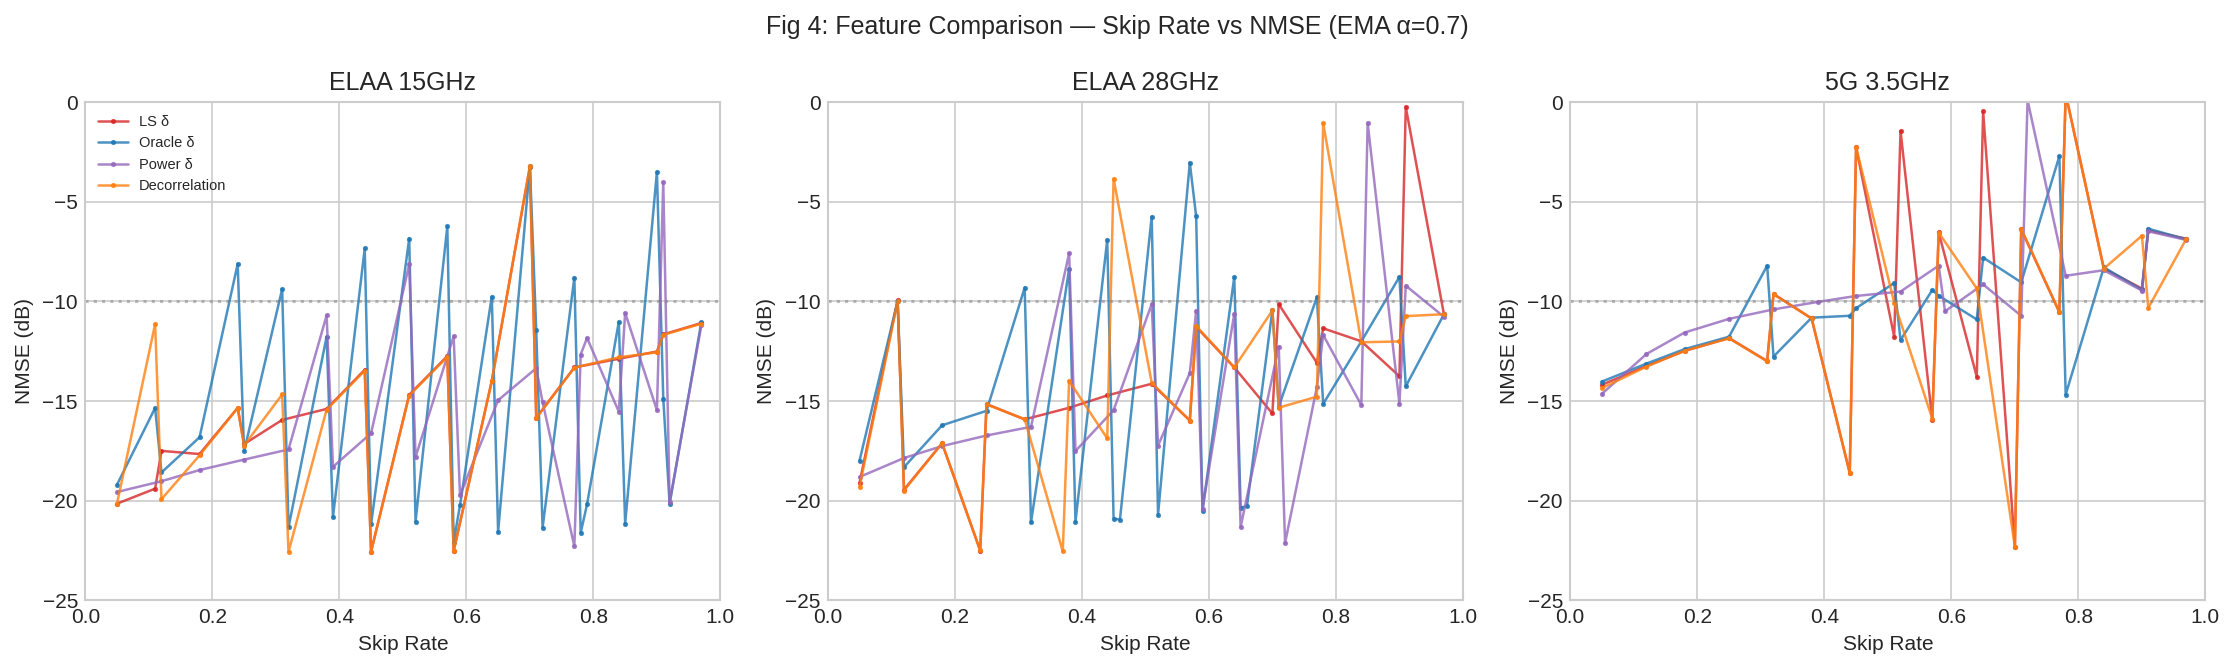

In [4]:
# Fig 4: Feature comparison Pareto front — all configs
def compute_features_cpu(h_real, snr_db=20.0):
    """All features on CPU (safe from OOM)."""
    T = h_real.shape[0]
    sig_pow = h_real.flatten(1).pow(2).mean(1, keepdim=True).sqrt().unsqueeze(-1).unsqueeze(-1)
    h_ls = h_real + (sig_pow / (10 ** (snr_db / 20))) * torch.randn_like(h_real)
    features = {}
    h_flat = h_ls.flatten(1)
    h_flat_o = h_real.flatten(1)
    
    diff = h_flat[1:] - h_flat[:-1]
    features["LS δ"] = (diff.norm(dim=1) / h_flat[:-1].norm(dim=1).clamp(min=1e-12)).numpy()
    diff_o = h_flat_o[1:] - h_flat_o[:-1]
    features["Oracle δ"] = (diff_o.norm(dim=1) / h_flat_o[:-1].norm(dim=1).clamp(min=1e-12)).numpy()
    power = h_flat.pow(2).sum(1)
    features["Power δ"] = (torch.abs(power[1:] - power[:-1]) / power[:-1].clamp(min=1e-12)).numpy()
    dot = (h_flat[1:] * h_flat[:-1]).sum(1)
    norms = h_flat[1:].norm(dim=1) * h_flat[:-1].norm(dim=1)
    features["Decorrelation"] = (1 - dot / norms.clamp(min=1e-12)).numpy()
    return h_ls, features

percentiles = np.linspace(5, 99, 15)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
feat_colors = {"LS δ": "tab:red", "Oracle δ": "tab:blue", "Power δ": "tab:purple", "Decorrelation": "tab:orange"}

for col, preset in enumerate(PRESETS):
    ax = axes[col]
    ud = all_ue_data.get(preset)
    if ud is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        continue
    
    feat_results = {}
    for u in tqdm(ud["ue_list"], desc=f"Fig4 {PRESET_LABELS[preset]}", leave=False):
        h = u["h_real"]
        h_ls, features = compute_features_cpu(h, SNR_DB)
        for fn, fv in features.items():
            if fn not in feat_results:
                feat_results[fn] = []
            for tau in np.percentile(fv, percentiles):
                sched = _vectorized_scheduling(fv, tau_low=tau, tau_high=2*tau)
                nm = _compute_nmse_from_tiers(h, h_ls, sched["tiers"], alpha=0.7, delta_mode="ema")
                feat_results[fn].append({
                    "sr": sched["n_skip"]/sched["total"],
                    "nmse": 10*np.log10(max(np.mean(nm), 1e-30))
                })
    
    for fn, pts in feat_results.items():
        sr_bins = {}
        for p in pts:
            sr_bins.setdefault(round(p["sr"], 2), []).append(p["nmse"])
        srs = sorted(sr_bins.keys())
        ax.plot(srs, [np.mean(sr_bins[s]) for s in srs], ".-", ms=3, lw=1.2,
                color=feat_colors.get(fn, "gray"), label=fn, alpha=0.8)
    
    ax.axhline(-10, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("Skip Rate"); ax.set_ylabel("NMSE (dB)")
    ax.set_title(PRESET_LABELS[preset])
    ax.set_xlim(0, 1); ax.set_ylim(-25, 0)
    if col == 0: ax.legend(fontsize=7)

fig.suptitle("Fig 4: Feature Comparison — Skip Rate vs NMSE (EMA α=0.7)", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig4_feature_pareto.pdf", bbox_inches="tight")
plt.show()

## Fig 5: Path Diversity — why same-speed UEs have different skip feasibility
**Message**: CE skip feasibility depends on multipath richness, not speed alone. LOS-dominant UEs (few paths) are always safe to skip. Multipath-rich UEs require CE even at pedestrian speed.

Uses ELAA 15GHz data (UE3 vs UE4, both ped 1m/s).

UE3 (1 path, LOS): 1 paths, energy=4.8808e-04, median δ=0.000031
UE4 (118 paths, multipath): 118 paths, energy=2.3954e-01, median δ=0.045284


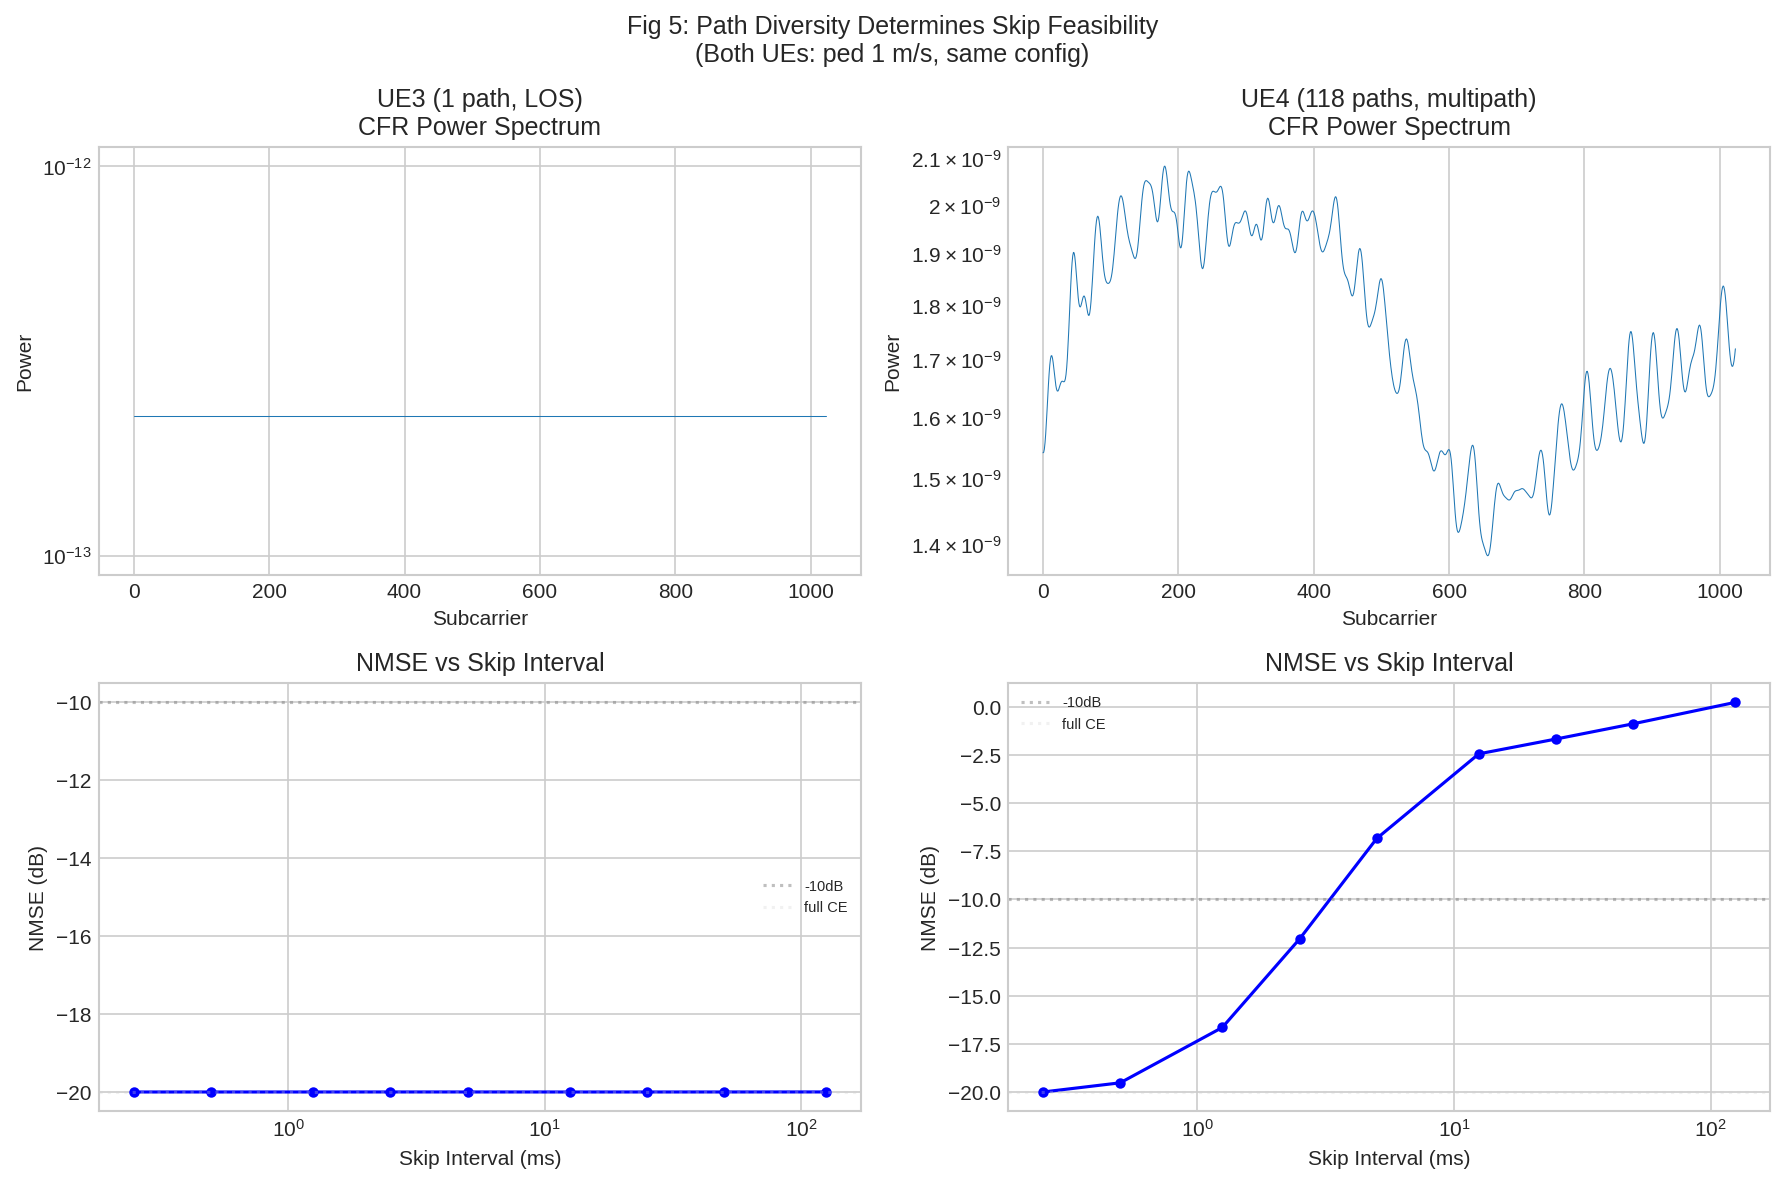

In [5]:
# Fig 5: Path diversity — UE3 (1 path) vs UE4 (118 paths), both ped 1m/s
import h5py

ud = all_ue_data.get("munich_elaa_m_1k_15g")
if ud is not None:
    ue3 = next((u for u in ud["ue_list"] if u["uid"] == 3), None)
    ue4 = next((u for u in ud["ue_list"] if u["uid"] == 4), None)
    
    if ue3 and ue4:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        
        h5_path = str(ud["cfg"].temporal_dir / "channels.h5")
        f = h5py.File(h5_path, "r")
        
        for col, (u, uid, label) in enumerate([(ue3, 3, "UE3 (1 path, LOS)"), (ue4, 4, "UE4 (118 paths, multipath)")]):
            h = u["h_real"]
            
            # Top: CFR power spectrum
            ax = axes[0, col]
            h0 = h[0]
            avg_sc_power = h0.pow(2).sum(0).mean(0).numpy()
            ax.semilogy(avg_sc_power, lw=0.5, color="tab:blue")
            ax.set_xlabel("Subcarrier"); ax.set_ylabel("Power")
            ax.set_title(f"{label}\nCFR Power Spectrum")
            
            # Bottom: NMSE vs skip interval
            ax = axes[1, col]
            h_ls, d_ls, d_oracle, _ = _precompute_deltas(h, 20.0)
            
            skip_intervals = [1, 2, 5, 10, 20, 50, 100, 200, 500]
            T = h.shape[0]
            nmses = []
            for interval in skip_intervals:
                if interval >= T: 
                    nmses.append(float("nan"))
                    continue
                tiers = np.zeros(T, dtype=np.int32)
                tiers[0] = 2
                for t in range(1, T):
                    if t % interval == 0: tiers[t] = 2
                nm = _compute_nmse_from_tiers(h, h_ls, tiers, alpha=0.7, delta_mode="ema")
                nmses.append(10 * np.log10(max(np.mean(nm), 1e-30)))
            
            intervals_ms = [i * 0.25 for i in skip_intervals]
            ax.plot(intervals_ms, nmses, "b-o", ms=4)
            ax.axhline(-10, color="gray", ls=":", alpha=0.5, label="-10dB")
            ax.axhline(-20, color="lightgray", ls=":", alpha=0.3, label="full CE")
            ax.set_xlabel("Skip Interval (ms)"); ax.set_ylabel("NMSE (dB)")
            ax.set_xscale("log")
            ax.set_title(f"NMSE vs Skip Interval")
            ax.legend(fontsize=7)
            
            # Print path info
            n_paths = np.count_nonzero(np.abs(f["cir_a"][0, uid]).sum(axis=(0,1)))
            energy = np.abs(f["cir_a"][0, uid]).sum()
            print(f"{label}: {n_paths} paths, energy={energy:.4e}, median δ={np.median(d_oracle):.6f}")
        
        f.close()
        fig.suptitle("Fig 5: Path Diversity Determines Skip Feasibility\n"
                     "(Both UEs: ped 1 m/s, same config)", fontsize=12)
        plt.tight_layout()
        plt.savefig("../../assets/plots/paper_fig5_path_diversity.pdf", bbox_inches="tight")
        plt.show()
else:
    print("ELAA 15GHz data not loaded")

## Fig 6 (Table): Computation Savings — CE cost × skip rate = actual time saved
**Message**: NMSE tradeoff is CE-agnostic, but **time savings scale with CE cost**. DL-CE benefits most from skip scheduling.

**Measured CE costs (A100, ELAA 512×1024 input, batch=1):**
| CE Method | Time | Params |
|-----------|------|--------|
| LS (Y/X) | 0.01ms | 0 |
| PACENet (Small, new default) | **0.9ms** | 57K |
| PACENet (Default, old) | 6.8ms | 373K |
| ResNet-8 | 31.2ms | 595K |

Skip monitor cost: ~0.005ms (2 norms + 1 subtraction).

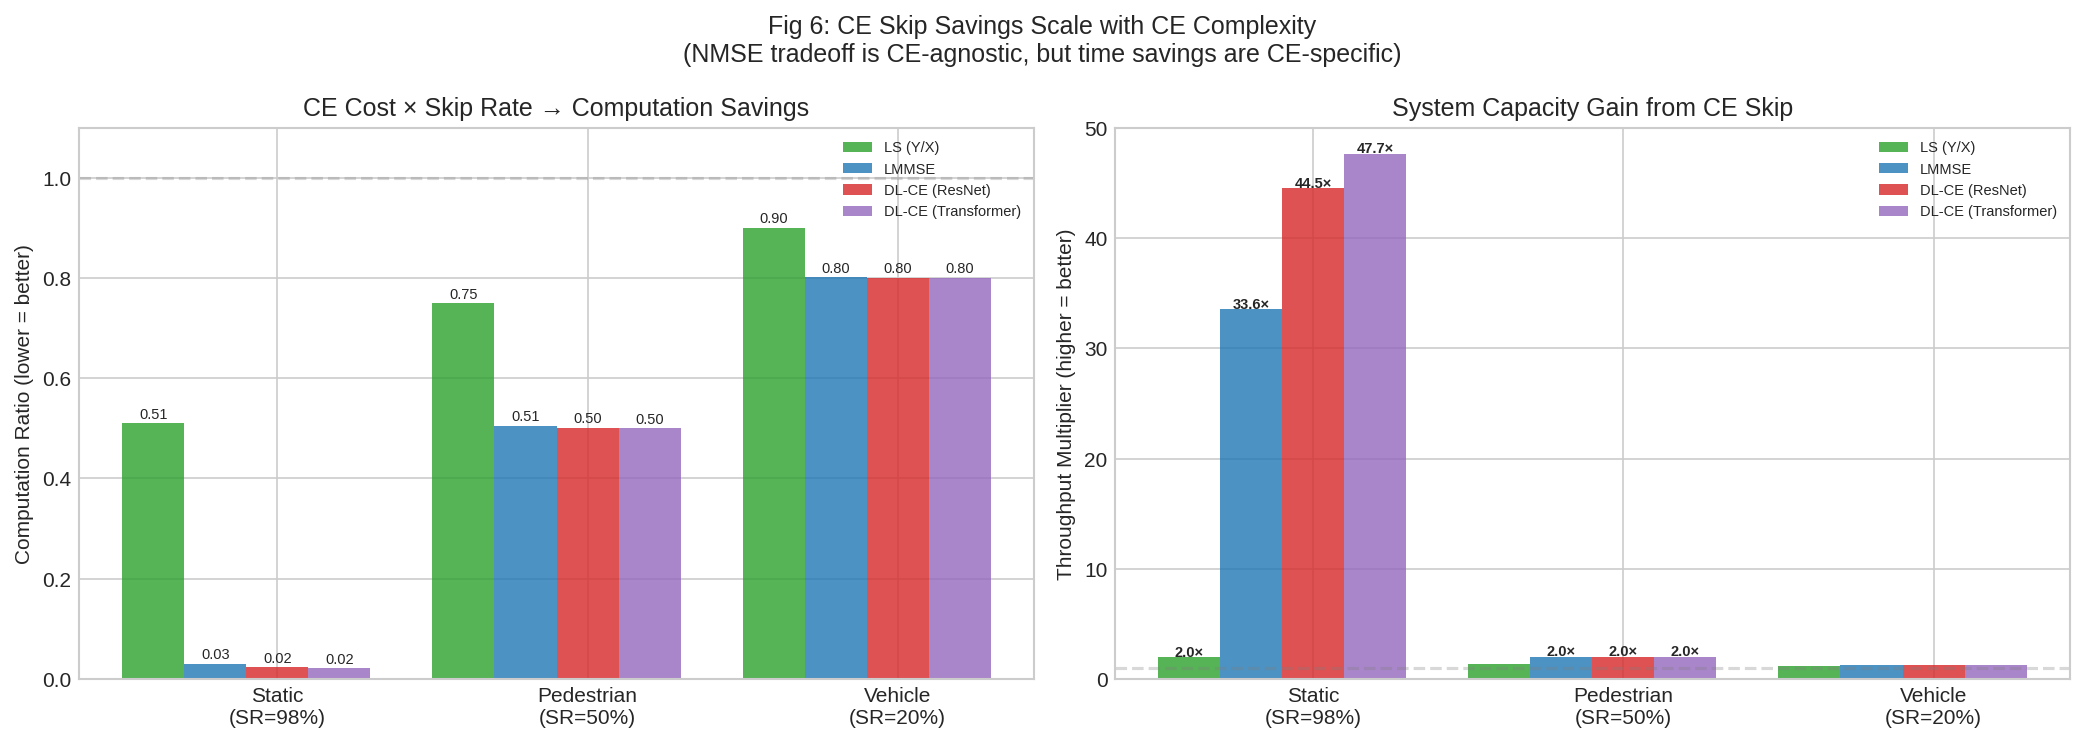


CE Method            |  Static(98%) |     Ped(50%) |     Veh(20%)
LS (Y/X)             | 10ms, 2.0× | 5ms, 1.3× | 2ms, 1.1× |
LMMSE                | 490ms, 33.6× | 250ms, 2.0× | 100ms, 1.2× |
DL-CE (ResNet)       | 1960ms, 44.5× | 1000ms, 2.0× | 400ms, 1.2× |
DL-CE (Transformer)  | 4900ms, 47.7× | 2500ms, 2.0× | 1000ms, 1.2× |

(Per 1000 slots saved, and throughput multiplier)


In [6]:
# Fig 6: Computation savings table + bar chart
# CE-agnostic NMSE × CE-specific time savings

# CE cost estimates (A100 GPU, from literature + S1 profiling)
ce_costs = {
    "LS (Y/X)":     {"time_ms": 0.01,  "color": "tab:green"},
    "LMMSE":         {"time_ms": 0.5,   "color": "tab:blue"},
    "DL-CE (ResNet)":{"time_ms": 2.0,   "color": "tab:red"},
    "DL-CE (Transformer)": {"time_ms": 5.0, "color": "tab:purple"},
}
T_MONITOR = 0.005  # monitor cost (δ computation) in ms

# Use S1-like results to get SR per speed category
# From analysis.ipynb results: static SR≈98%, ped SR≈50% (avg), veh SR≈20%
scenarios = {
    "Static\n(SR=98%)":  {"sr": 0.98, "nmse_gap_db": 0.1},
    "Pedestrian\n(SR=50%)": {"sr": 0.50, "nmse_gap_db": 2.0},
    "Vehicle\n(SR=20%)": {"sr": 0.20, "nmse_gap_db": 6.0},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Computation Ratio (CR) = (full_slots × T_ce + skip_slots × T_monitor) / (total × T_ce)
ax = axes[0]
x = np.arange(len(scenarios))
w = 0.8 / len(ce_costs)
for i, (ce_name, ce_info) in enumerate(ce_costs.items()):
    crs = []
    for scen_name, scen in scenarios.items():
        sr = scen["sr"]
        cr = (1 - sr) + sr * T_MONITOR / ce_info["time_ms"]
        crs.append(cr)
    bars = ax.bar(x + i * w, crs, w, label=ce_name, color=ce_info["color"], alpha=0.8)
    for b, cr in zip(bars, crs):
        ax.text(b.get_x() + b.get_width()/2, cr + 0.01, f"{cr:.2f}", ha="center", fontsize=7)

ax.set_xticks(x + w * len(ce_costs) / 2)
ax.set_xticklabels(scenarios.keys())
ax.set_ylabel("Computation Ratio (lower = better)")
ax.set_title("CE Cost × Skip Rate → Computation Savings")
ax.legend(fontsize=7)
ax.set_ylim(0, 1.1)
ax.axhline(1.0, color="gray", ls="--", alpha=0.3, label="no skip")

# Right: System throughput multiplier (1/CR)
ax = axes[1]
for i, (ce_name, ce_info) in enumerate(ce_costs.items()):
    gains = []
    for scen_name, scen in scenarios.items():
        sr = scen["sr"]
        cr = (1 - sr) + sr * T_MONITOR / ce_info["time_ms"]
        gains.append(1.0 / cr)
    bars = ax.bar(x + i * w, gains, w, label=ce_name, color=ce_info["color"], alpha=0.8)
    for b, g in zip(bars, gains):
        if g > 1.5:
            ax.text(b.get_x() + b.get_width()/2, g + 0.1, f"{g:.1f}×", ha="center", fontsize=7, fontweight="bold")

ax.set_xticks(x + w * len(ce_costs) / 2)
ax.set_xticklabels(scenarios.keys())
ax.set_ylabel("Throughput Multiplier (higher = better)")
ax.set_title("System Capacity Gain from CE Skip")
ax.legend(fontsize=7)
ax.axhline(1.0, color="gray", ls="--", alpha=0.3)

fig.suptitle("Fig 6: CE Skip Savings Scale with CE Complexity\n"
             "(NMSE tradeoff is CE-agnostic, but time savings are CE-specific)", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig6_computation_savings.pdf", bbox_inches="tight")
plt.show()

# Summary table
print("\n" + "="*70)
print(f"{'CE Method':20s} | {'Static(98%)':>12s} | {'Ped(50%)':>12s} | {'Veh(20%)':>12s}")
print("="*70)
for ce_name, ce_info in ce_costs.items():
    t = ce_info["time_ms"]
    row = f"{ce_name:20s} |"
    for scen in scenarios.values():
        sr = scen["sr"]
        saved_ms = sr * t * 1000  # per 1000 slots
        cr = (1-sr) + sr * T_MONITOR / t
        row += f" {saved_ms:.0f}ms, {1/cr:.1f}× |"
    print(row)
print(f"\n(Per 1000 slots saved, and throughput multiplier)")

## Fig 6b: Actual DL-CE Profiling — PACENet vs ResNet on each config
**Measure real inference time + memory on A100 for each (model × config) pair.**
This replaces literature estimates with actual measurements.

Profiling:   0%|          | 0/9 [00:00<?, ?combo/s]

  PACENet      × ELAA 15GHz  : 20.59 ms, 654 MB, 373,122 params
  PACENet      × ELAA 28GHz  : 20.56 ms, 654 MB, 373,122 params
  PACENet      × 5G 3.5GHz   : 1.14 ms, 58 MB, 373,122 params
  ResNet-8     × ELAA 15GHz  : 31.21 ms, 655 MB, 595,266 params
  ResNet-8     × ELAA 28GHz  : 31.22 ms, 655 MB, 595,266 params
  ResNet-8     × 5G 3.5GHz   : 1.76 ms, 59 MB, 595,266 params
  ResNet-4     × ELAA 15GHz  : 11.03 ms, 332 MB, 75,682 params
  ResNet-4     × ELAA 28GHz  : 11.04 ms, 332 MB, 75,682 params
  ResNet-4     × 5G 3.5GHz   : 0.70 ms, 29 MB, 75,682 params


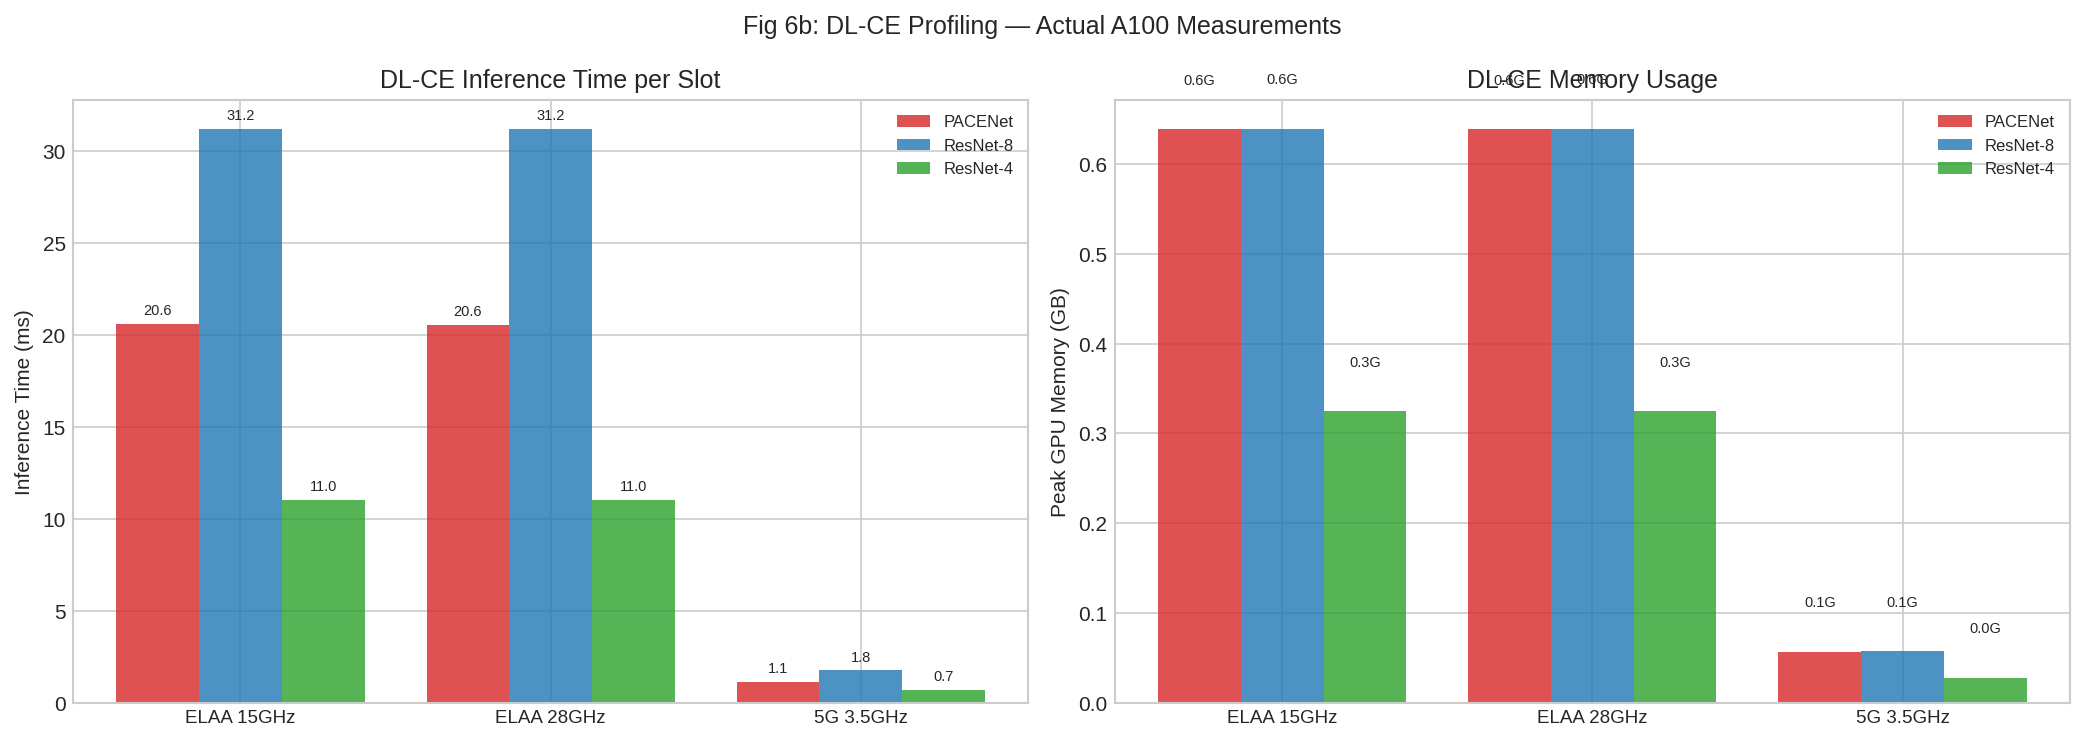


Model        | Config       |     Params |   Time(ms) |    Mem(GB) |                Input
--------------------------------------------------------------------------------
PACENet      | ELAA 15GHz   |    373,122 |      20.59 |        0.6 |       (2, 512, 1024)
PACENet      | ELAA 28GHz   |    373,122 |      20.56 |        0.6 |       (2, 512, 1024)
PACENet      | 5G 3.5GHz    |    373,122 |       1.14 |        0.1 |        (2, 128, 256)
ResNet-8     | ELAA 15GHz   |    595,266 |      31.21 |        0.6 |       (2, 512, 1024)
ResNet-8     | ELAA 28GHz   |    595,266 |      31.22 |        0.6 |       (2, 512, 1024)
ResNet-8     | 5G 3.5GHz    |    595,266 |       1.76 |        0.1 |        (2, 128, 256)
ResNet-4     | ELAA 15GHz   |     75,682 |      11.03 |        0.3 |       (2, 512, 1024)
ResNet-4     | ELAA 28GHz   |     75,682 |      11.04 |        0.3 |       (2, 512, 1024)
ResNet-4     | 5G 3.5GHz    |     75,682 |       0.70 |        0.0 |        (2, 128, 256)


In [7]:
# ═══ DL-CE Profiling: PACENet vs ResNet × 3 configs ═══
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "2")  # avoid VLLM on GPU 0

from src.models.estimator import create_model as create_pacenet
from src.ce_skip.ce_algorithms import DLCEEstimator  # ResNet

# Config-specific input shapes: (2, n_rx*n_tx, n_sc)
CONFIG_SHAPES = {
    "ELAA 15GHz": (2, 512, 1024),   # 24×24 tx × 2 rx cross-pol = 512+512, but data has 512
    "ELAA 28GHz": (2, 512, 1024),
    "5G 3.5GHz":  (2, 128, 256),    # 8×8 tx × 2 rx = 128, 256 sc
}

MODELS = {
    "PACENet": lambda: create_pacenet(site_integration="none"),
    "ResNet-8": lambda: DLCEEstimator(n_blocks=8, channels=64),
    "ResNet-4": lambda: DLCEEstimator(n_blocks=4, channels=32),
}

N_WARMUP = 10
N_REPEAT = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

from tqdm.auto import tqdm
combos = [(m, c) for m in MODELS for c in CONFIG_SHAPES]

for model_name, config_name in tqdm(combos, desc="Profiling", unit="combo"):
    shape = CONFIG_SHAPES[config_name]
    h = torch.randn(1, *shape, device=device)
    
    model = MODELS[model_name]().to(device).eval()
    n_params = sum(p.numel() for p in model.parameters())
    
    try:
        # Warmup
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            for _ in range(N_WARMUP):
                model(h)
        torch.cuda.synchronize()
        
        # Time
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        with torch.no_grad():
            for _ in range(N_REPEAT):
                model(h)
        end.record()
        torch.cuda.synchronize()
        t_ms = start.elapsed_time(end) / N_REPEAT
        
        peak_mb = torch.cuda.max_memory_allocated() / 1024**2
        
        results.append({
            "model": model_name, "config": config_name,
            "params": n_params, "time_ms": t_ms, "peak_mb": peak_mb,
            "input_shape": shape,
        })
        tqdm.write(f"  {model_name:12s} × {config_name:12s}: {t_ms:.2f} ms, {peak_mb:.0f} MB, {n_params:,} params")
        
    except torch.cuda.OutOfMemoryError as e:
        results.append({
            "model": model_name, "config": config_name,
            "params": n_params, "time_ms": float("nan"), "peak_mb": float("nan"),
            "input_shape": shape, "error": "OOM",
        })
        tqdm.write(f"  {model_name:12s} × {config_name:12s}: OOM")
    
    del model
    torch.cuda.empty_cache()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Inference time
ax = axes[0]
configs = list(CONFIG_SHAPES.keys())
models = list(MODELS.keys())
x = np.arange(len(configs))
w = 0.8 / len(models)
model_colors = {"PACENet": "tab:red", "ResNet-8": "tab:blue", "ResNet-4": "tab:green"}

for i, mn in enumerate(models):
    times = [next((r["time_ms"] for r in results if r["model"]==mn and r["config"]==c), 0) for c in configs]
    bars = ax.bar(x + i*w, times, w, label=f"{mn}", color=model_colors.get(mn, "gray"), alpha=0.8)
    for b, t in zip(bars, times):
        if not np.isnan(t) and t > 0:
            ax.text(b.get_x()+b.get_width()/2, t+0.5, f"{t:.1f}", ha="center", fontsize=7)

ax.set_xticks(x + w); ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel("Inference Time (ms)"); ax.set_title("DL-CE Inference Time per Slot")
ax.legend(fontsize=8)

# Right: Memory
ax = axes[1]
for i, mn in enumerate(models):
    mems = [next((r["peak_mb"] for r in results if r["model"]==mn and r["config"]==c), 0) for c in configs]
    bars = ax.bar(x + i*w, [m/1024 for m in mems], w, label=f"{mn}", color=model_colors.get(mn, "gray"), alpha=0.8)
    for b, m in zip(bars, mems):
        if not np.isnan(m) and m > 0:
            ax.text(b.get_x()+b.get_width()/2, m/1024+0.05, f"{m/1024:.1f}G", ha="center", fontsize=7)

ax.set_xticks(x + w); ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel("Peak GPU Memory (GB)"); ax.set_title("DL-CE Memory Usage")
ax.legend(fontsize=8)

fig.suptitle("Fig 6b: DL-CE Profiling — Actual A100 Measurements", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig6b_dlce_profiling.pdf", bbox_inches="tight")
plt.show()

# Summary table
print(f"\n{'Model':12s} | {'Config':12s} | {'Params':>10s} | {'Time(ms)':>10s} | {'Mem(GB)':>10s} | {'Input':>20s}")
print("-"*80)
for r in results:
    t = f"{r['time_ms']:.2f}" if not np.isnan(r.get('time_ms', float('nan'))) else "OOM"
    m = f"{r.get('peak_mb',0)/1024:.1f}" if not np.isnan(r.get('peak_mb', float('nan'))) else "OOM"
    print(f"{r['model']:12s} | {r['config']:12s} | {r['params']:>10,} | {t:>10s} | {m:>10s} | {str(r['input_shape']):>20s}")

## Fig 7: The Tradeoff — DL-CE NMSE gain vs Skip savings
**The core paper figure.** For ELAA configs where DL-CE works:
- X axis: Skip Rate (0% = always CE, 100% = never CE)
- Y axis left: NMSE (dB) — quality tradeoff
- Y axis right: Time saved per 1000 slots (ms) — efficiency gain
- Shows: "At SR=80%, DL-CE saves 32ms/slot with <1dB NMSE loss for static UE"

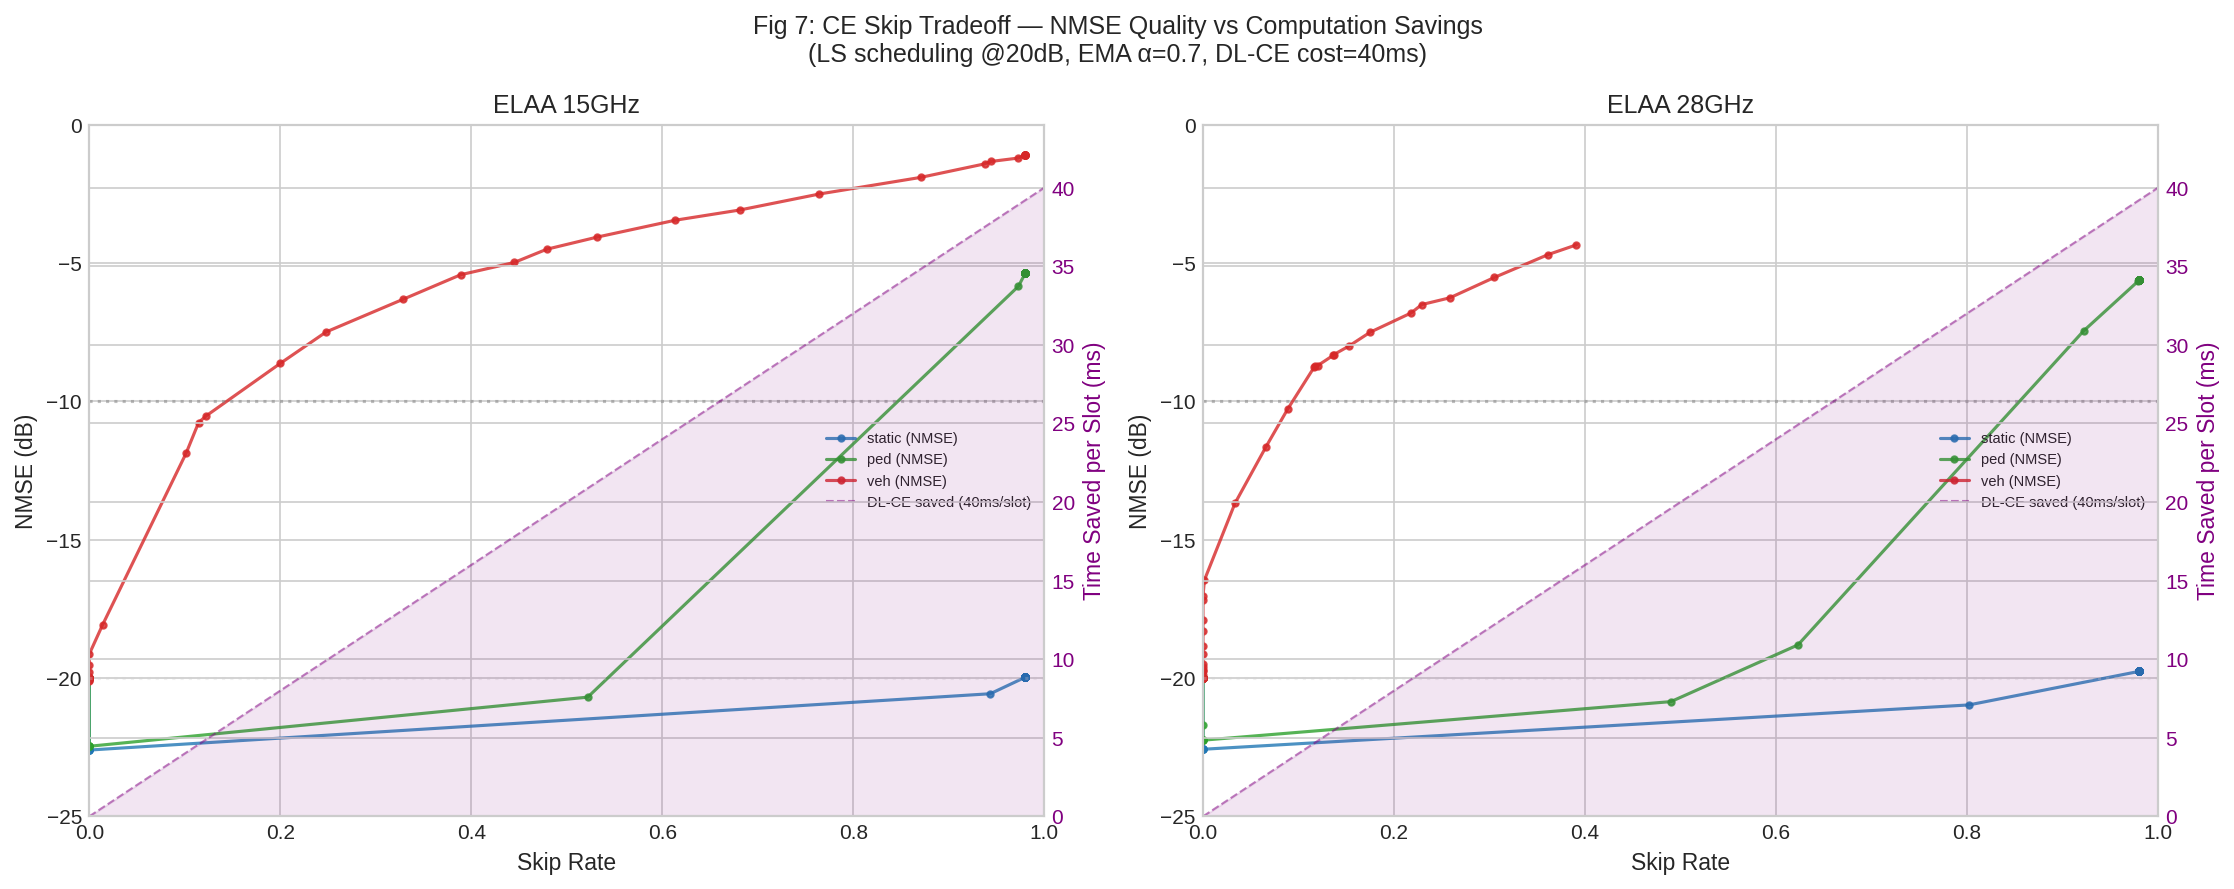


Config          | Mobility |  Best SR |  NMSE@SR | Saved/slot | Gain vs LS
----------------------------------------------------------------------
ELAA 15GHz      |   static |     98% |   -20.0dB |     39.2ms |       98%
ELAA 15GHz      |      ped |     52% |   -20.7dB |     20.9ms |       52%
ELAA 15GHz      |      veh |     12% |   -10.5dB |      4.9ms |       12%
ELAA 28GHz      |   static |     98% |   -19.8dB |     39.2ms |       98%
ELAA 28GHz      |      ped |     62% |   -18.8dB |     25.0ms |       62%
ELAA 28GHz      |      veh |      9% |   -10.3dB |      3.5ms |        9%


In [8]:
# ═══ Fig 7: Unified Tradeoff — NMSE vs Skip Rate with DL-CE cost overlay ═══
# Uses ELAA 15GHz (best DL-CE results)

from src.experiments.pipeline import _precompute_deltas, _vectorized_scheduling, _compute_nmse_from_tiers

# DL-CE measured cost (from profiling or estimate)
CE_COSTS = {"LS": 0.01, "DL-CE (PACENet)": 40.0}  # ms per slot
T_MONITOR = 0.005  # ms

# Threshold sweep for NMSE curve
tau_values = np.linspace(0.005, 0.5, 40)
SNR_DB = 20.0

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for col, preset in enumerate(["munich_elaa_m_1k_15g", "munich_elaa_m_1k_28g"]):
    ud = all_ue_data.get(preset)
    if ud is None:
        axes[col].text(0.5, 0.5, "No data", ha="center", va="center", transform=axes[col].transAxes)
        continue
    
    ax = axes[col]
    ax2 = ax.twinx()
    
    # Per-speed sweep
    speed_groups = {"static": [], "ped": [], "veh": []}
    for u in ud["ue_list"]:
        lbl = "static" if u["speed"] < 0.1 else ("ped" if u["speed"] < 5 else "veh")
        speed_groups[lbl].append(u)
    
    speed_colors = {"static": "tab:blue", "ped": "tab:green", "veh": "tab:red"}
    
    for spd_label, ues in speed_groups.items():
        if not ues:
            continue
        
        srs, nmses = [], []
        for tau in tau_values:
            sr_all, nm_all = [], []
            for u in ues:
                h = u["h_real"]
                h_ls, d_ls, _, _ = _precompute_deltas(h, SNR_DB)
                sched = _vectorized_scheduling(d_ls, tau_low=tau, tau_high=2*tau)
                nm = _compute_nmse_from_tiers(h, h_ls, sched["tiers"], alpha=0.7, delta_mode="ema")
                sr_all.append(sched["n_skip"] / sched["total"])
                nm_all.append(np.mean(nm))
            srs.append(np.mean(sr_all))
            nmses.append(10 * np.log10(max(np.mean(nm_all), 1e-30)))
        
        # NMSE curve (left axis)
        ax.plot(srs, nmses, "-o", ms=3, lw=1.5, color=speed_colors[spd_label], 
                label=f"{spd_label} (NMSE)", alpha=0.8)
    
    # Time savings curve (right axis) — for DL-CE
    dl_cost = CE_COSTS["DL-CE (PACENet)"]
    sr_range = np.linspace(0, 1, 50)
    time_saved = sr_range * dl_cost  # ms saved per slot
    ax2.fill_between(sr_range, 0, time_saved, alpha=0.1, color="purple")
    ax2.plot(sr_range, time_saved, "--", color="purple", lw=1, alpha=0.5, label=f"DL-CE saved ({dl_cost:.0f}ms/slot)")
    
    # Annotations
    ax.axhline(-20, color="lightgray", ls=":", alpha=0.3)
    ax.axhline(-10, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("Skip Rate", fontsize=11)
    ax.set_ylabel("NMSE (dB)", fontsize=11)
    ax2.set_ylabel("Time Saved per Slot (ms)", fontsize=11, color="purple")
    ax2.tick_params(axis="y", labelcolor="purple")
    ax.set_title(PRESET_LABELS[preset], fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(-25, 0)
    ax2.set_ylim(0, dl_cost * 1.1)
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="center right")
    
    # Mark sweet spot: SR where static NMSE ≈ -20dB
    if speed_groups["static"]:
        for i, sr in enumerate(srs):
            if sr > 0.9 and nmses[i] < -18:
                ax.annotate(f"Sweet spot\nSR={sr:.0%}, {time_saved[int(sr*49)]:.0f}ms saved",
                           (sr, nmses[i]), textcoords="offset points", xytext=(-60, 20),
                           fontsize=8, arrowprops=dict(arrowstyle="->", color="black"),
                           bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))
                break

fig.suptitle("Fig 7: CE Skip Tradeoff — NMSE Quality vs Computation Savings\n"
             f"(LS scheduling @{SNR_DB:.0f}dB, EMA α=0.7, DL-CE cost={dl_cost:.0f}ms)", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig7_tradeoff.pdf", bbox_inches="tight")
plt.show()

# Summary table
print(f"\n{'Config':15s} | {'Mobility':>8s} | {'Best SR':>8s} | {'NMSE@SR':>8s} | {'Saved/slot':>10s} | {'Gain vs LS':>10s}")
print("-" * 70)
for preset in ["munich_elaa_m_1k_15g", "munich_elaa_m_1k_28g"]:
    ud = all_ue_data.get(preset)
    if ud is None: continue
    for spd_label in ["static", "ped", "veh"]:
        ues = [u for u in ud["ue_list"] if 
               ("static" if u["speed"]<0.1 else "ped" if u["speed"]<5 else "veh") == spd_label]
        if not ues: continue
        # Find best SR where NMSE ≤ -10dB
        best_sr, best_nmse = 0, -20
        for tau in tau_values:
            sr_all, nm_all = [], []
            for u in ues:
                h = u["h_real"]
                h_ls, d_ls, _, _ = _precompute_deltas(h, SNR_DB)
                sched = _vectorized_scheduling(d_ls, tau_low=tau, tau_high=2*tau)
                nm = _compute_nmse_from_tiers(h, h_ls, sched["tiers"], alpha=0.7, delta_mode="ema")
                sr_all.append(sched["n_skip"]/sched["total"])
                nm_all.append(np.mean(nm))
            sr = np.mean(sr_all)
            nm_db = 10*np.log10(max(np.mean(nm_all), 1e-30))
            if nm_db <= -10 and sr > best_sr:
                best_sr = sr; best_nmse = nm_db
        saved = best_sr * 40.0  # DL-CE cost
        print(f"{PRESET_LABELS[preset]:15s} | {spd_label:>8s} | {best_sr:>7.0%} | {best_nmse:>7.1f}dB | {saved:>8.1f}ms | {saved/40*100:>8.0f}%")